In [17]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import gymnasium as gym
from collections import defaultdict

# Reproducibility
np.random.seed(42)
print(f"Gymnasium version: {gym.__version__}")

Gymnasium version: 1.2.1


In [18]:
ENV_NAME       = "Blackjack-v1"
NUM_EPISODES   = 500_000
GAMMA          = 1.0        # undiscounted — standard for Blackjack
EPSILON_START  = 0.1
EPSILON_END    = 0.01
DECAY_EPISODES = 400_000

print("Hyperparameters set:")
print(f"  Episodes   : {NUM_EPISODES:,}")
print(f"  Gamma      : {GAMMA}")
print(f"  ε start    : {EPSILON_START}")
print(f"  ε end      : {EPSILON_END}")
print(f"  ε decay ep : {DECAY_EPISODES:,}")

Hyperparameters set:
  Episodes   : 500,000
  Gamma      : 1.0
  ε start    : 0.1
  ε end      : 0.01
  ε decay ep : 400,000


In [19]:
env = gym.make(ENV_NAME)

print("Observation space :", env.observation_space)
print("Action space      :", env.action_space)
print("  0 = Stick  |  1 = Hit")
print()

# Sample a few random episodes to understand the structure
for ep in range(3):
    obs, info = env.reset()
    print(f"Episode {ep+1} start state: player_sum={obs[0]}, dealer={obs[1]}, usable_ace={obs[2]}")
    done = False
    steps = 0
    while not done:
        action = env.action_space.sample()
        obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        steps += 1
    print(f"  → {steps} step(s), final reward: {reward}")

env.close()

Observation space : Tuple(Discrete(32), Discrete(11), Discrete(2))
Action space      : Discrete(2)
  0 = Stick  |  1 = Hit

Episode 1 start state: player_sum=12, dealer=2, usable_ace=0
  → 1 step(s), final reward: -1.0
Episode 2 start state: player_sum=12, dealer=10, usable_ace=0
  → 1 step(s), final reward: -1.0
Episode 3 start state: player_sum=17, dealer=1, usable_ace=1
  → 2 step(s), final reward: -1.0


In [20]:
def epsilon_greedy_policy(Q, state, n_actions, epsilon):
   
    # Start: every action gets ε / |A|
    probs = np.ones(n_actions) * epsilon / n_actions

    best_action = np.argmax(Q[state])

    
    probs[best_action] += (1 - epsilon)        # Fix 1 : (1 - epsilon)
   

    return probs


# ── Quick sanity check ──
Q_test    = defaultdict(lambda: np.zeros(2))
Q_test[(15, 6, False)][1] = 0.5   # action 1 (Hit) is greedy
p = epsilon_greedy_policy(Q_test, (15, 6, False), 2, epsilon=0.1)
print("Action probs (should sum to 1.0):", p)
print("Sum:", p.sum())   # ← will print 1.1 until bug is fixed

Action probs (should sum to 1.0): [0.05 0.95]
Sum: 1.0


In [21]:
def generate_episode(env, Q, epsilon):
  
    episode = []

   
    state, _ = env.reset()       # Fix 2: state, _ = env.reset()

    terminated = False

    while not terminated:
        probs  = epsilon_greedy_policy(Q, state, env.action_space.n, epsilon)
        action = np.random.choice(env.action_space.n, p=probs)
        next_state, reward, terminated, truncated, _ = env.step(action)
        episode.append((state, action, reward))
        state = next_state

    return episode


# ── Quick sanity check ──
env_test = gym.make(ENV_NAME)
Q_test   = defaultdict(lambda: np.zeros(2))
ep_test  = generate_episode(env_test, Q_test, epsilon=0.1)
print(f"Episode length: {len(ep_test)} step(s)")
print(f"First state type: {type(ep_test[0][0])}")
print(f"First state value: {ep_test[0][0]}")  # Should be a tuple like (18, 6, False)
env_test.close()

Episode length: 1 step(s)
First state type: <class 'tuple'>
First state value: (15, 10, 0)


In [22]:
def mc_control(env, num_episodes, gamma, epsilon_start, epsilon_end, decay_episodes):
    
    Q       = defaultdict(lambda: np.zeros(env.action_space.n))
    returns = defaultdict(list)


    # visited_sa = set()   # Fix

    returns_log = []   # stores per-episode return for learning curve

    for episode_num in range(num_episodes):
        visited_sa = set()   # Fix
        # Linear ε decay
        epsilon = max(
            epsilon_end,
            epsilon_start - (epsilon_start - epsilon_end) * (episode_num / decay_episodes)
        )

        episode = generate_episode(env, Q, epsilon)

        # ── Compute returns & update Q ──────────────────────────────────────
        G = 0

        for (state, action, reward) in reversed(episode):           # Fixed to reversed(episode)
            G = gamma * G + reward
            visited_sa = set()
            sa_pair = (state, action)
            if sa_pair not in visited_sa:   # first-visit check
                visited_sa.add(sa_pair)
                returns[sa_pair].append(G)
                Q[state][action] = np.mean(returns[sa_pair])

        # Log total episode return
        episode_return = sum(r for (_, _, r) in episode)
        returns_log.append(episode_return)

        if (episode_num + 1) % 50_000 == 0:
            recent_avg = np.mean(returns_log[-10_000:])
            print(f"  Episode {episode_num+1:>7,} | ε={epsilon:.4f} | "
                  f"Avg return (last 10k): {recent_avg:+.4f}")

    return Q, returns_log

print("mc_control() defined")

mc_control() defined


# Train the Agent


In [23]:
import time

env = gym.make(ENV_NAME)

print("Starting training...")
print("=" * 55)

t0 = time.time()

Q, returns_log = mc_control(
    env,
    num_episodes   = NUM_EPISODES,
    gamma          = GAMMA,
    epsilon_start  = EPSILON_START,
    epsilon_end    = EPSILON_END,
    decay_episodes = DECAY_EPISODES,
)

env.close()

elapsed = time.time() - t0
print("=" * 55)
print(f"Training complete in {elapsed:.1f}s")
print(f"States learned: {len(Q):,}")
print(f"Final avg return (last 10k): {np.mean(returns_log[-10_000:]):+.4f}")

Starting training...
  Episode  50,000 | ε=0.0888 | Avg return (last 10k): -0.1074
  Episode 100,000 | ε=0.0775 | Avg return (last 10k): -0.0885
  Episode 150,000 | ε=0.0663 | Avg return (last 10k): -0.0768
  Episode 200,000 | ε=0.0550 | Avg return (last 10k): -0.0811
  Episode 250,000 | ε=0.0438 | Avg return (last 10k): -0.0630
  Episode 300,000 | ε=0.0325 | Avg return (last 10k): -0.0635
  Episode 350,000 | ε=0.0213 | Avg return (last 10k): -0.0581
  Episode 400,000 | ε=0.0100 | Avg return (last 10k): -0.0453
  Episode 450,000 | ε=0.0100 | Avg return (last 10k): -0.0388
  Episode 500,000 | ε=0.0100 | Avg return (last 10k): -0.0438
Training complete in 100.8s
States learned: 280
Final avg return (last 10k): -0.0438


In [24]:
def extract_value_and_policy(Q):
    """Derive V*(s) = max_a Q(s,a) and the greedy policy."""
    V      = defaultdict(float)
    policy = defaultdict(int)

    for state, actions in Q.items():
        V[state]      = np.max(actions)
        policy[state] = np.argmax(actions)

    return V, policy


V, policy = extract_value_and_policy(Q)

# Sample a few states
sample_states = [(18, 6, False), (15, 10, False), (20, 5, True), (12, 3, True)]
print(f"{'State':<30} {'V(s)':>8}  {'Action'}")
print("-" * 50)
for s in sample_states:
    act = "Hit" if policy[s] == 1 else "Stick"
    print(f"  player={s[0]}, dealer={s[1]}, ace={s[2]}    {V[s]:>+6.3f}   {act}")

State                              V(s)  Action
--------------------------------------------------
  player=18, dealer=6, ace=False    +0.278   Stick
  player=15, dealer=10, ace=False    -0.547   Hit
  player=20, dealer=5, ace=True    +0.639   Stick
  player=12, dealer=3, ace=True    +0.087   Hit


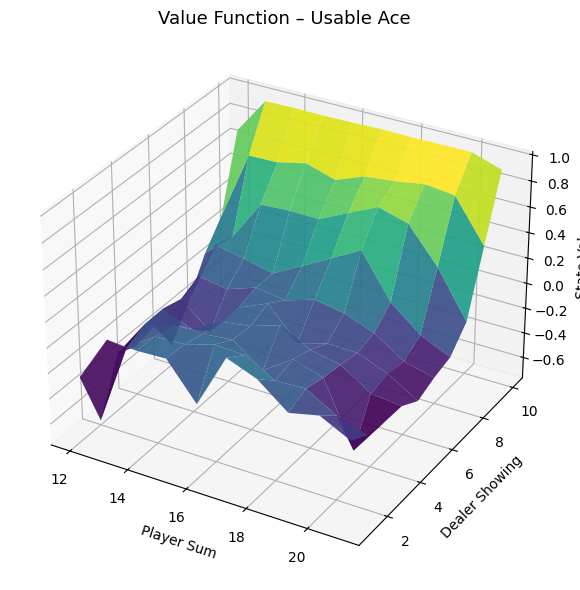

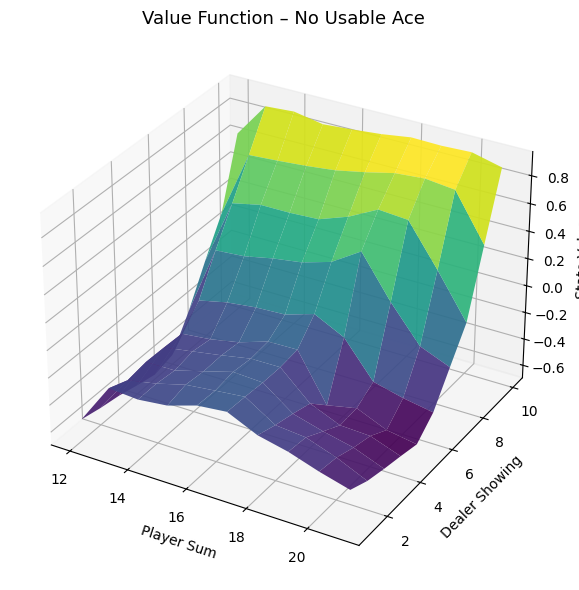

In [25]:
def plot_value_function(V, title):
    
    player_sums  = np.arange(12, 22)   # 10 values: 12–21
    dealer_cards = np.arange(1, 11)    # 10 values: 1–10
 
    
    X, Y = np.meshgrid(player_sums, dealer_cards)   # Fixed
  

    Z = np.zeros_like(X, dtype=float)
    usable = "usable" in title.lower() and "no" not in title.lower()

    for i, ps in enumerate(player_sums):
        for j, dc in enumerate(dealer_cards):
            Z[i, j] = V.get((ps, dc, usable), 0.0)

    fig = plt.figure(figsize=(10, 6))
    ax  = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.92)

    ax.set_xlabel("Player Sum")       # labels are also wrong due to the bug
    ax.set_ylabel("Dealer Showing")
    ax.set_zlabel("State Value")
    ax.set_title(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_').replace('–','')}.png", dpi=150)
    plt.show()


plot_value_function(V, "Value Function – Usable Ace")
plot_value_function(V, "Value Function – No Usable Ace")

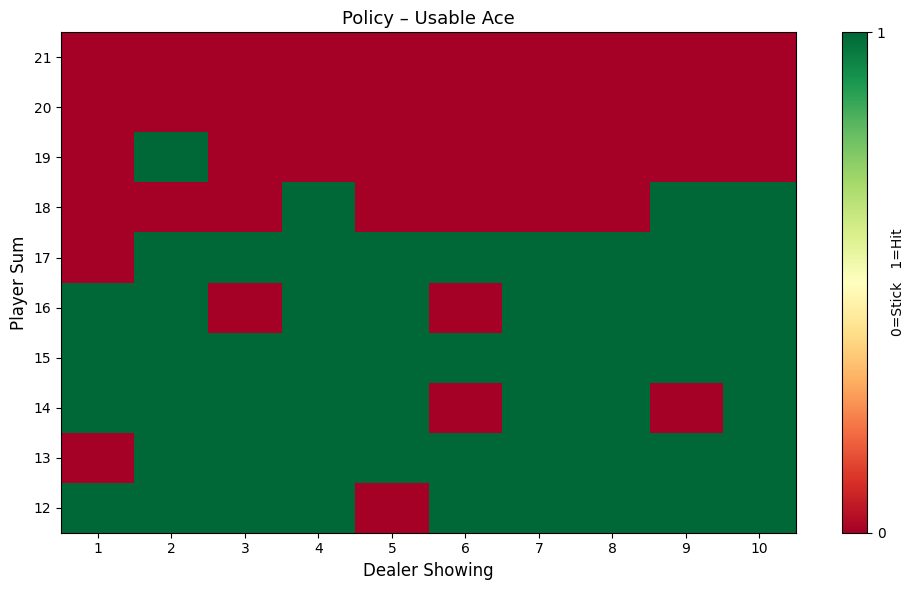

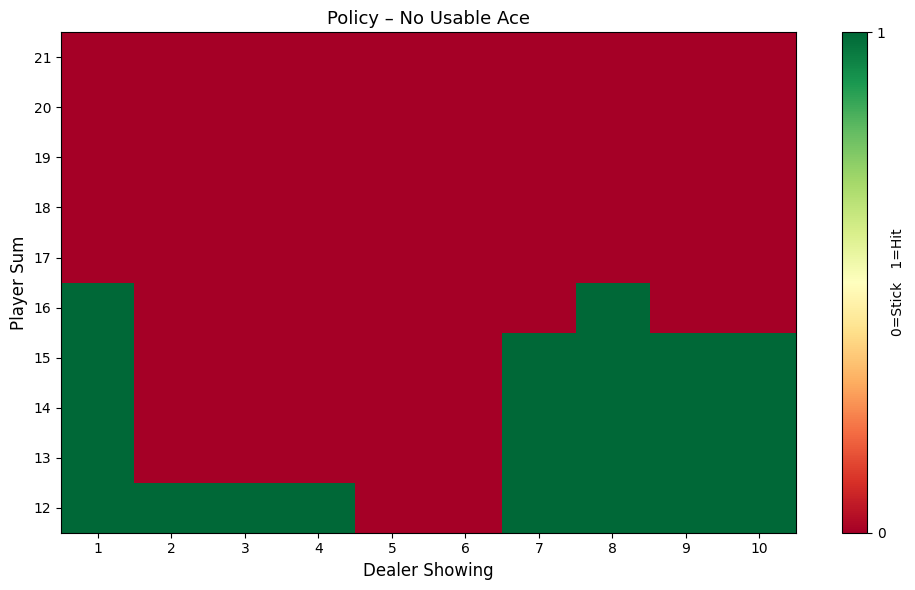

In [26]:
def plot_policy(policy, title):
    """Heatmap of learned policy: 0=Stick (green), 1=Hit (red)."""
    player_sums  = np.arange(12, 22)
    dealer_cards = np.arange(1, 11)
    usable = "usable" in title.lower() and "no" not in title.lower()

    grid = np.zeros((len(player_sums), len(dealer_cards)), dtype=int)
    for i, ps in enumerate(player_sums):
        for j, dc in enumerate(dealer_cards):
            grid[i, j] = policy.get((ps, dc, usable), 1)

    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(grid, cmap='RdYlGn', aspect='auto',
                   origin='lower', vmin=0, vmax=1)
    ax.set_xticks(np.arange(len(dealer_cards)))
    ax.set_xticklabels(dealer_cards)
    ax.set_yticks(np.arange(len(player_sums)))
    ax.set_yticklabels(player_sums)
    ax.set_xlabel("Dealer Showing", fontsize=12)
    ax.set_ylabel("Player Sum", fontsize=12)
    ax.set_title(title, fontsize=13)
    plt.colorbar(im, ax=ax, ticks=[0, 1], label="0=Stick   1=Hit")
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_').replace('–','')}_policy.png", dpi=150)
    plt.show()


plot_policy(policy, "Policy – Usable Ace")
plot_policy(policy, "Policy – No Usable Ace")

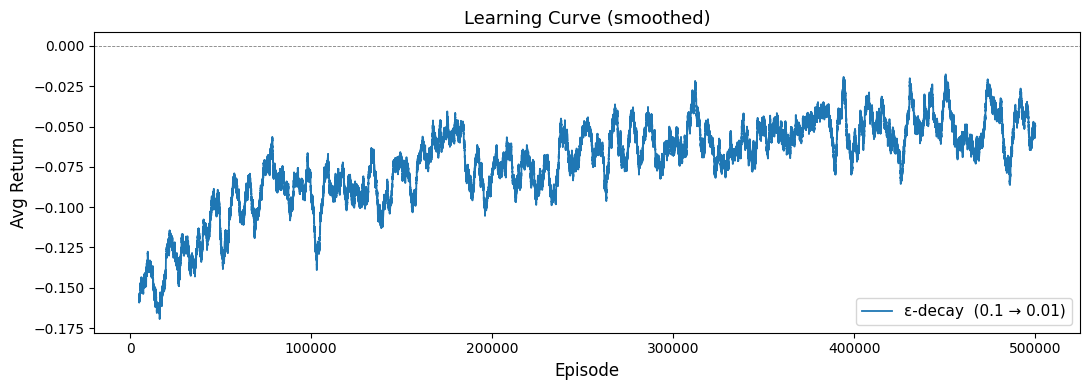

In [27]:
def plot_learning_curve(returns_log, window=1000, label=""):
    """
    Plots smoothed average return over episodes.

    BUG 6: x = np.arange(len(returns_log)) has the wrong length after
           convolve 'valid' mode trims (window-1) values from the output.
    HINT : x should start at (window - 1):  np.arange(window-1, len(returns_log))
    """
    kernel   = np.ones(window) / window
    smoothed = np.convolve(returns_log, kernel, mode='valid')

    x = np.arange(window - 1, len(returns_log))   # ← WRONG length — causes ValueError

    plt.figure(figsize=(11, 4))
    plt.plot(x, smoothed, linewidth=1.3, label=label or f"window={window:,}")
    plt.axhline(0, color='gray', linewidth=0.6, linestyle='--')
    plt.xlabel("Episode", fontsize=12)
    plt.ylabel("Avg Return", fontsize=12)
    plt.title("Learning Curve (smoothed)", fontsize=13)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.savefig("learning_curve.png", dpi=150)
    plt.show()


plot_learning_curve(returns_log, window=5000, label="ε-decay  (0.1 → 0.01)")


Training with fixed ε = 0.05 …
  Episode  50,000 | ε=0.0500 | Avg return (last 10k): -0.1021
  Episode 100,000 | ε=0.0500 | Avg return (last 10k): -0.0949
  Episode 150,000 | ε=0.0500 | Avg return (last 10k): -0.0781
  Episode 200,000 | ε=0.0500 | Avg return (last 10k): -0.0866

Training with fixed ε = 0.1 …
  Episode  50,000 | ε=0.1000 | Avg return (last 10k): -0.1000
  Episode 100,000 | ε=0.1000 | Avg return (last 10k): -0.0961
  Episode 150,000 | ε=0.1000 | Avg return (last 10k): -0.0766
  Episode 200,000 | ε=0.1000 | Avg return (last 10k): -0.0685

Training with fixed ε = 0.3 …
  Episode  50,000 | ε=0.3000 | Avg return (last 10k): -0.1457
  Episode 100,000 | ε=0.3000 | Avg return (last 10k): -0.1611
  Episode 150,000 | ε=0.3000 | Avg return (last 10k): -0.1384
  Episode 200,000 | ε=0.3000 | Avg return (last 10k): -0.1643


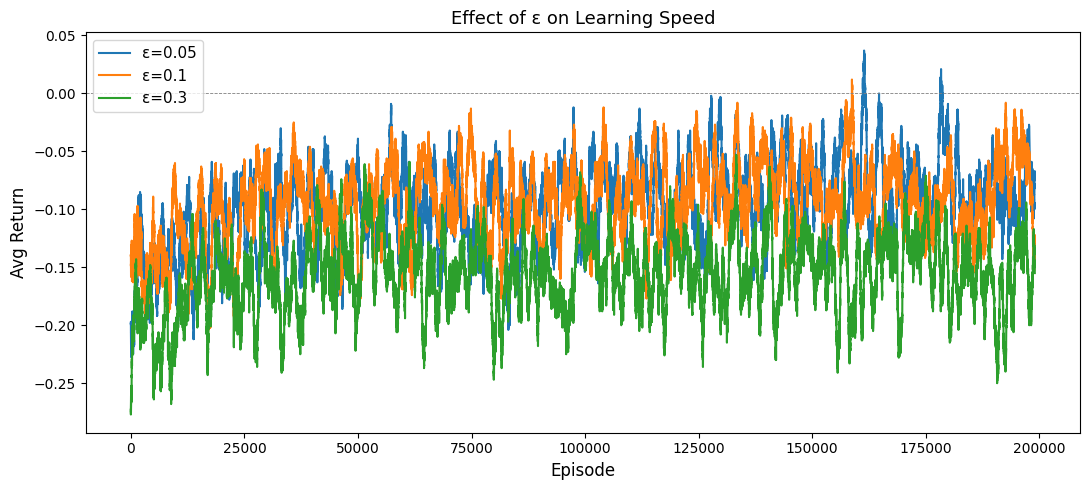

In [28]:
def run_epsilon_experiment(epsilons, num_episodes=200_000, window=1000):
    """Train one agent per fixed ε value and overlay their learning curves."""
    env = gym.make(ENV_NAME)
    plt.figure(figsize=(11, 5))

    for eps in epsilons:
        print(f"\nTraining with fixed ε = {eps} …")
        _, ret_log = mc_control(
            env,
            num_episodes   = num_episodes,
            gamma          = GAMMA,
            epsilon_start  = eps,
            epsilon_end    = eps,          # fixed — no decay
            decay_episodes = num_episodes,
        )
        kernel   = np.ones(window) / window
        smoothed = np.convolve(ret_log, kernel, mode='valid')
       
        plt.plot(smoothed, label=f"ε={eps}")

    env.close()
    plt.axhline(0, color='gray', linewidth=0.6, linestyle='--')
    plt.xlabel("Episode", fontsize=12)
    plt.ylabel("Avg Return", fontsize=12)
    plt.title("Effect of ε on Learning Speed", fontsize=13)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.savefig("epsilon_comparison.png", dpi=150)
    plt.show()


run_epsilon_experiment(epsilons=[0.05, 0.1, 0.3], num_episodes=200_000)

In [29]:
def basic_strategy(player_sum, dealer_card, usable_ace):
    """Simplified basic Blackjack strategy. Returns 1=Hit, 0=Stick."""
    if usable_ace:
        if player_sum >= 19:              return 0  # Stick
        if player_sum == 18:
            return 0 if dealer_card in range(2, 9) else 1
        return 1  # Hit on soft 17 or below
    else:
        if player_sum >= 17:              return 0  # Stick
        if player_sum <= 11:              return 1  # Always Hit
        if player_sum in range(13, 17):
            return 1 if dealer_card in [7, 8, 9, 10, 1] else 0
        return 1  # Hit on 12


# Agreement rate between learned policy and basic strategy
player_sums  = range(12, 22)
dealer_cards = range(1, 11)

for usable in [False, True]:
    agree = total = 0
    for ps in player_sums:
        for dc in dealer_cards:
            state = (ps, dc, usable)
            mc_act    = policy.get(state, 1)
            basic_act = basic_strategy(ps, dc, usable)
            if mc_act == basic_act:
                agree += 1
            total += 1
    label = "Usable Ace" if usable else "No Usable Ace"
    print(f"[{label}]  Agreement with basic strategy: {agree}/{total}  ({100*agree/total:.1f}%)")

[No Usable Ace]  Agreement with basic strategy: 95/100  (95.0%)
[Usable Ace]  Agreement with basic strategy: 90/100  (90.0%)
